In [27]:
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

print("\n[0.1] DOWNLOADING DATASET")
print("-" * 40)

# Dataset URL
DATASET_URL = "https://www.dropbox.com/scl/fi/2jibh9twr8jml97mqtyki/churn_uplift_anonymized.csv?rlkey=907ib1npo2a9zk27ot5ra6zsg&dl=1"

# Create data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
data_path = data_dir / "churn_uplift_anonymized.csv"

# Download dataset
try:
    if not data_path.exists():
        print(f"Downloading dataset from Dropbox...")
        import urllib.request
        urllib.request.urlretrieve(DATASET_URL, data_path)
        print(f"Dataset downloaded to: {data_path}")
    else:
        print(f"Dataset already exists at: {data_path}")
except Exception as e:
    print(f"Could not download automatically: {e}")
    print("\nPlease download manually:")
    print(f"1. Visit: {DATASET_URL}")
    print(f"2. Save as: {data_path}")
    print("\nThen run the script again.")
    # Don't raise - allow manual download


[0.1] DOWNLOADING DATASET
----------------------------------------
Dataset already exists at: data/churn_uplift_anonymized.csv


In [28]:
# Standard libraries
from scipy import stats

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting (PDF Requirement)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Uplift Modeling (Uber's CausalML - PDF Requirement)
from causalml.inference.meta import BaseTRegressor, BaseSRegressor
from causalml.metrics import auuc_score, qini_score

# Explainability (SHAP - PDF Requirement)
import shap

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully")

# =============================================================================
# SECTION 2: LOAD AND INSPECT DATASET
# =============================================================================

print("\n" + "=" * 80)
print("SECTION 2: DATASET INSPECTION")
print("=" * 80)

print("\n[2.1] LOADING DATASET")
print("-" * 40)

# Load dataset
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Display basic info
print("\n[2.2] DATASET OVERVIEW")
print("-" * 40)
print(f"Total features: {df.shape[1] - 2} (excluding 't' and 'y')")
print(f"Treatment column: 't'")
print(f"Outcome column: 'y'")

print(f"\nTreatment distribution:")
print(df['t'].value_counts())
print(f"Treatment rate: {df['t'].mean():.2%}")

print(f"\nOutcome distribution:")
print(df['y'].value_counts())
print(f"Churn rate: {df['y'].mean():.2%}")

# Check for missing values
print("\n[2.3] MISSING VALUES")
print("-" * 40)
missing = df.isnull().sum().sum()
if missing > 0:
    print(f" Found {missing} missing values")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print(" No missing values")

# Identify column types
print("\n[2.4] FEATURE TYPES")
print("-" * 40)

# PC columns (numeric)
pc_cols = [col for col in df.columns if col.startswith('PC')]
print(f"Principal Components (PC): {len(pc_cols)} columns")

# FACTOR columns (categorical)
factor_cols = [col for col in df.columns if col.startswith('FACTOR')]
print(f"Categorical Features (FACTOR): {len(factor_cols)} columns")

# Other columns
other_cols = [col for col in df.columns if col not in pc_cols + factor_cols + ['t', 'y']]
if other_cols:
    print(f"Other columns: {other_cols}")

print(f"\nTotal features: {len(pc_cols) + len(factor_cols)} (178 as expected)")

All libraries imported successfully

SECTION 2: DATASET INSPECTION

[2.1] LOADING DATASET
----------------------------------------
Dataset loaded successfully!
Shape: 11,896 rows × 180 columns

[2.2] DATASET OVERVIEW
----------------------------------------
Total features: 178 (excluding 't' and 'y')
Treatment column: 't'
Outcome column: 'y'

Treatment distribution:
t
1    9010
0    2886
Name: count, dtype: int64
Treatment rate: 75.74%

Outcome distribution:
y
0    11488
1      408
Name: count, dtype: int64
Churn rate: 3.43%

[2.3] MISSING VALUES
----------------------------------------
 No missing values

[2.4] FEATURE TYPES
----------------------------------------
Principal Components (PC): 160 columns
Categorical Features (FACTOR): 18 columns

Total features: 178 (178 as expected)


In [29]:
print("\n" + "=" * 80)
print("SECTION 3: DATA PREPROCESSING")
print("=" * 80)

print("\n[3.1] ENCODING CATEGORICAL FEATURES")
print("-" * 40)

# Create a copy for processing
df_processed = df.copy()

# Encode FACTOR columns
label_encoders = {}

for col in factor_cols:
    print(f"Encoding {col}... ", end='')
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f" ({len(le.classes_)} categories)")

print(f"\n Encoded {len(factor_cols)} categorical features")

# Verify all features are now numeric
print("\n[3.2] VERIFYING DATA TYPES")
print("-" * 40)

feature_cols = [col for col in df_processed.columns if col not in ['t', 'y']]
non_numeric = df_processed[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric:
    print(f" Still have non-numeric columns: {non_numeric}")
else:
    print(f" All {len(feature_cols)} features are now numeric")

# Prepare arrays
print("\n[3.3] PREPARING DATA ARRAYS")
print("-" * 40)

X = df_processed[feature_cols].values
y = df_processed['y'].values
treatment = df_processed['t'].values

print(f"Feature matrix (X): {X.shape}")
print(f"Outcome vector (y): {y.shape}")
print(f"Treatment vector:   {treatment.shape}")

# Check for any NaN or Inf values
print("\n[3.4] DATA QUALITY CHECK")
print("-" * 40)

nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

if nan_count > 0:
    print(f"  Found {nan_count} NaN values")
    # Fill NaN with column median
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = imputer.fit_transform(X)
    print(f" NaN values imputed with median")
else:
    print(f" No NaN values")

if inf_count > 0:
    print(f"  Found {inf_count} Inf values")
    X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
    print(f" Inf values replaced")
else:
    print(f" No Inf values")


SECTION 3: DATA PREPROCESSING

[3.1] ENCODING CATEGORICAL FEATURES
----------------------------------------
Encoding FACTOR1...  (18 categories)
Encoding FACTOR2...  (12 categories)
Encoding FACTOR3...  (1 categories)
Encoding FACTOR4...  (20 categories)
Encoding FACTOR5...  (4 categories)
Encoding FACTOR6...  (20 categories)
Encoding FACTOR7...  (3 categories)
Encoding FACTOR8...  (2 categories)
Encoding FACTOR9...  (4 categories)
Encoding FACTOR10...  (4 categories)
Encoding FACTOR11...  (3 categories)
Encoding FACTOR12...  (3 categories)
Encoding FACTOR13...  (12 categories)
Encoding FACTOR14...  (20 categories)
Encoding FACTOR15...  (20 categories)
Encoding FACTOR16...  (17 categories)
Encoding FACTOR17...  (6 categories)
Encoding FACTOR18...  (7 categories)

 Encoded 18 categorical features

[3.2] VERIFYING DATA TYPES
----------------------------------------
 All 178 features are now numeric

[3.3] PREPARING DATA ARRAYS
----------------------------------------
Feature matrix (X):

In [30]:
print("\n" + "=" * 80)
print("SECTION 4: TRAIN-VALIDATION-TEST SPLIT (60-20-20)")
print("=" * 80)

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test, t_temp, t_test = train_test_split(
    X, y, treatment,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: 75% train, 25% val (of temp = 60% and 20% of total)
X_train, X_val, y_train, y_val, t_train, t_val = train_test_split(
    X_temp, y_temp, t_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Training set:   {X_train.shape[0]:>6,} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Validation set: {X_val.shape[0]:>6,} samples ({X_val.shape[0]/len(X):.1%})")
print(f"Test set:       {X_test.shape[0]:>6,} samples ({X_test.shape[0]/len(X):.1%})")

print(f"\nOutcome distribution:")
print(f"  Train:      {y_train.mean():.2%} churn")
print(f"  Validation: {y_val.mean():.2%} churn")
print(f"  Test:       {y_test.mean():.2%} churn")

print(f"\nTreatment distribution:")
print(f"  Train:      {t_train.mean():.2%} treated")
print(f"  Validation: {t_val.mean():.2%} treated")
print(f"  Test:       {t_test.mean():.2%} treated")

# Feature scaling
print("\n[4.1] FEATURE SCALING")
print("-" * 40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(" Features standardized (mean   =0, std=1)")


SECTION 4: TRAIN-VALIDATION-TEST SPLIT (60-20-20)
Training set:    7,137 samples (60.0%)
Validation set:  2,379 samples (20.0%)
Test set:        2,380 samples (20.0%)

Outcome distribution:
  Train:      3.42% churn
  Validation: 3.45% churn
  Test:       3.45% churn

Treatment distribution:
  Train:      75.03% treated
  Validation: 76.42% treated
  Test:       77.18% treated

[4.1] FEATURE SCALING
----------------------------------------
 Features standardized (mean   =0, std=1)


In [31]:
print("\n" + "=" * 80)
print("SECTION 5: CHURN PREDICTION MODELS")
print("=" * 80)

results = {}

# Class imbalance ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"\nClass imbalance — neg: {neg_count:,}  pos: {pos_count:,}  ratio: {scale_pos_weight:.1f}x")
print("Using class_weight='balanced' (RF/LGB) and scale_pos_weight (XGB).\n")

from sklearn.metrics import precision_recall_curve

def optimal_threshold_f1(y_true, y_proba):
    """Return threshold that maximises F1 on the given set."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-10)
    return float(thr[f1.argmax()])

# ── 5.1 Random Forest ────────────────────────────────────────────────────────
print("[5.1] RANDOM FOREST (BASELINE)")
print("-" * 40)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

rf_pred_proba = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_thresh     = optimal_threshold_f1(y_val, rf_pred_proba)
rf_pred       = (rf_pred_proba >= rf_thresh).astype(int)

results['RandomForest'] = {
    'AUC':       roc_auc_score(y_val, rf_pred_proba),
    'F1':        f1_score(y_val, rf_pred, zero_division=0),
    'Precision': precision_score(y_val, rf_pred, zero_division=0),
    'Recall':    recall_score(y_val, rf_pred, zero_division=0)
}
print(f"  Optimal threshold: {rf_thresh:.4f}")
for metric, value in results['RandomForest'].items():
    print(f"  {metric:10s}: {value:.4f}")

# ── 5.2 XGBoost ──────────────────────────────────────────────────────────────
print("\n[5.2] XGBOOST (PRIMARY MODEL)")
print("-" * 40)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print("Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train,
              eval_set=[(X_val_scaled, y_val)], verbose=False)

xgb_pred_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_thresh     = optimal_threshold_f1(y_val, xgb_pred_proba)
xgb_pred       = (xgb_pred_proba >= xgb_thresh).astype(int)

results['XGBoost'] = {
    'AUC':       roc_auc_score(y_val, xgb_pred_proba),
    'F1':        f1_score(y_val, xgb_pred, zero_division=0),
    'Precision': precision_score(y_val, xgb_pred, zero_division=0),
    'Recall':    recall_score(y_val, xgb_pred, zero_division=0)
}
print(f"  Optimal threshold: {xgb_thresh:.4f}")
for metric, value in results['XGBoost'].items():
    status = 'Yes' if (metric == 'AUC' and value >= 0.85) or (metric == 'F1' and value >= 0.75) else ''
    print(f"  {metric:10s}: {value:.4f} {status}")

# ── 5.3 LightGBM ─────────────────────────────────────────────────────────────
print("\n[5.3] LIGHTGBM (PRIMARY MODEL)")
print("-" * 40)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
print("Training LightGBM...")
lgb_model.fit(X_train_scaled, y_train,
              eval_set=[(X_val_scaled, y_val)], eval_metric='auc')

lgb_pred_proba = lgb_model.predict_proba(X_val_scaled)[:, 1]
lgb_thresh     = optimal_threshold_f1(y_val, lgb_pred_proba)
lgb_pred       = (lgb_pred_proba >= lgb_thresh).astype(int)

results['LightGBM'] = {
    'AUC':       roc_auc_score(y_val, lgb_pred_proba),
    'F1':        f1_score(y_val, lgb_pred, zero_division=0),
    'Precision': precision_score(y_val, lgb_pred, zero_division=0),
    'Recall':    recall_score(y_val, lgb_pred, zero_division=0)
}
print(f"  Optimal threshold: {lgb_thresh:.4f}")
for metric, value in results['LightGBM'].items():
    status = 'Yes' if (metric == 'AUC' and value >= 0.85) or (metric == 'F1' and value >= 0.75) else ''
    print(f"  {metric:10s}: {value:.4f} {status}")

# ── 5.4 Model Comparison ─────────────────────────────────────────────────────
print("\n[5.4] MODEL COMPARISON")
print("-" * 40)

comparison_df = pd.DataFrame(results).T
comparison_df['Meets AUC >= 0.85'] = comparison_df['AUC'] >= 0.85
comparison_df['Meets F1 >= 0.75']  = comparison_df['F1']  >= 0.75
print(comparison_df.to_string())

best_model_name = comparison_df['AUC'].idxmax()
best_model_dict = {'RandomForest': rf_model, 'XGBoost': xgb_model, 'LightGBM': lgb_model}
best_thresh_dict = {'RandomForest': rf_thresh, 'XGBoost': xgb_thresh, 'LightGBM': lgb_thresh}
best_model  = best_model_dict[best_model_name]
best_thresh = best_thresh_dict[best_model_name]

print(f"\n Best Model: {best_model_name}")
print(f"   AUC:       {results[best_model_name]['AUC']:.4f}")
print(f"   F1:        {results[best_model_name]['F1']:.4f}")
print(f"   Threshold: {best_thresh:.4f}")



SECTION 5: CHURN PREDICTION MODELS

Class imbalance — neg: 6,893  pos: 244  ratio: 28.2x
Using class_weight='balanced' (RF/LGB) and scale_pos_weight (XGB).

[5.1] RANDOM FOREST (BASELINE)
----------------------------------------
Training Random Forest...
  Optimal threshold: 0.2686
  AUC       : 0.8088
  F1        : 0.2359
  Precision : 0.2035
  Recall    : 0.2805

[5.2] XGBOOST (PRIMARY MODEL)
----------------------------------------
Training XGBoost...
  Optimal threshold: 0.2247
  AUC       : 0.8060 
  F1        : 0.2624 
  Precision : 0.2086 
  Recall    : 0.3537 

[5.3] LIGHTGBM (PRIMARY MODEL)
----------------------------------------
Training LightGBM...
  Optimal threshold: 0.1650
  AUC       : 0.7835 
  F1        : 0.2169 
  Precision : 0.1502 
  Recall    : 0.3902 

[5.4] MODEL COMPARISON
----------------------------------------
                   AUC        F1  Precision    Recall  Meets AUC >= 0.85  Meets F1 >= 0.75
RandomForest  0.808786  0.235897   0.203540  0.280488     

In [32]:
print("\n" + "=" * 80)
print("SECTION 6: UPLIFT MODELING (UBER'S CAUSALML)")
print("=" * 80)

# 6.1 T-Learner
print("\n[6.1] T-LEARNER IMPLEMENTATION")
print("-" * 40)

base_learner_t = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
tlearner = BaseTRegressor(learner=base_learner_t)
tlearner.fit(X_train_scaled, treatment=t_train, y=y_train)
uplift_t = tlearner.predict(X_val_scaled)

print(f"T-Learner Uplift (validation set):")
print(f"  Mean: {uplift_t.mean():.4f}  Std: {uplift_t.std():.4f}")
print(f"  Min:  {uplift_t.min():.4f}  Max: {uplift_t.max():.4f}")

# 6.2 S-Learner
# Use a shallower RF so the treatment feature has enough influence
print("\n[6.2] S-LEARNER IMPLEMENTATION")
print("-" * 40)

base_learner_s = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,          # shallower — treatment feature can split earlier
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
slearner = BaseSRegressor(learner=base_learner_s)
slearner.fit(X_train_scaled, treatment=t_train, y=y_train)
uplift_s = slearner.predict(X_val_scaled)

print(f"S-Learner Uplift (validation set):")
print(f"  Mean: {uplift_s.mean():.4f}  Std: {uplift_s.std():.4f}")
print(f"  Min:  {uplift_s.min():.4f}  Max: {uplift_s.max():.4f}")

# 6.3 Uplift Evaluation
# CausalML auuc/qini expect treatment column as STRINGS
print("\n[6.3] UPLIFT MODEL EVALUATION")
print("-" * 40)

uplift_t_flat = uplift_t.flatten() if uplift_t.ndim > 1 else uplift_t
uplift_s_flat = uplift_s.flatten() if uplift_s.ndim > 1 else uplift_s

t_val_str = t_val.astype(str)   # '0' / '1' as strings

df_val_t = pd.DataFrame({'y': y_val, 't': t_val_str, 'uplift': uplift_t_flat})
df_val_s = pd.DataFrame({'y': y_val, 't': t_val_str, 'uplift': uplift_s_flat})

try:
    auuc_t = auuc_score(df_val_t, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    qini_t = qini_score(df_val_t, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    print("T-Learner metrics OK")
except Exception as e:
    print(f"T-Learner error: {e}")
    auuc_t = qini_t = 0.0

try:
    auuc_s = auuc_score(df_val_s, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    qini_s = qini_score(df_val_s, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    print("S-Learner metrics OK")
except Exception as e:
    print(f"S-Learner error: {e}")
    auuc_s = qini_s = 0.0

print(f"\nT-Learner  AUUC: {auuc_t:.4f}  Qini: {qini_t:.4f} {'Yes' if qini_t > 0.1 else 'No'} (>0.1)")
print(f"S-Learner  AUUC: {auuc_s:.4f}  Qini: {qini_s:.4f} {'Yes' if qini_s > 0.1 else 'No'} (>0.1)")

if qini_t >= qini_s:
    best_uplift_model  = tlearner
    best_uplift_name   = "T-Learner"
    best_uplift_scores = uplift_t
    best_auuc = auuc_t;  best_qini = qini_t
else:
    best_uplift_model  = slearner
    best_uplift_name   = "S-Learner"
    best_uplift_scores = uplift_s
    best_auuc = auuc_s;  best_qini = qini_s

print(f"\nBest Uplift Model: {best_uplift_name}  AUUC: {best_auuc:.4f}  Qini: {best_qini:.4f}")



SECTION 6: UPLIFT MODELING (UBER'S CAUSALML)

[6.1] T-LEARNER IMPLEMENTATION
----------------------------------------
T-Learner Uplift (validation set):
  Mean: 0.0017  Std: 0.0710
  Min:  -1.0000  Max: 1.0000

[6.2] S-LEARNER IMPLEMENTATION
----------------------------------------
S-Learner Uplift (validation set):
  Mean: 0.0000  Std: 0.0000
  Min:  0.0000  Max: 0.0000

[6.3] UPLIFT MODEL EVALUATION
----------------------------------------
T-Learner error: No objects to concatenate
S-Learner error: No objects to concatenate

T-Learner  AUUC: 0.0000  Qini: 0.0000 No (>0.1)
S-Learner  AUUC: 0.0000  Qini: 0.0000 No (>0.1)

Best Uplift Model: T-Learner  AUUC: 0.0000  Qini: 0.0000



[7.1] ROC Curves
----------------------------------------
 Saved: outputs/roc_curves.png


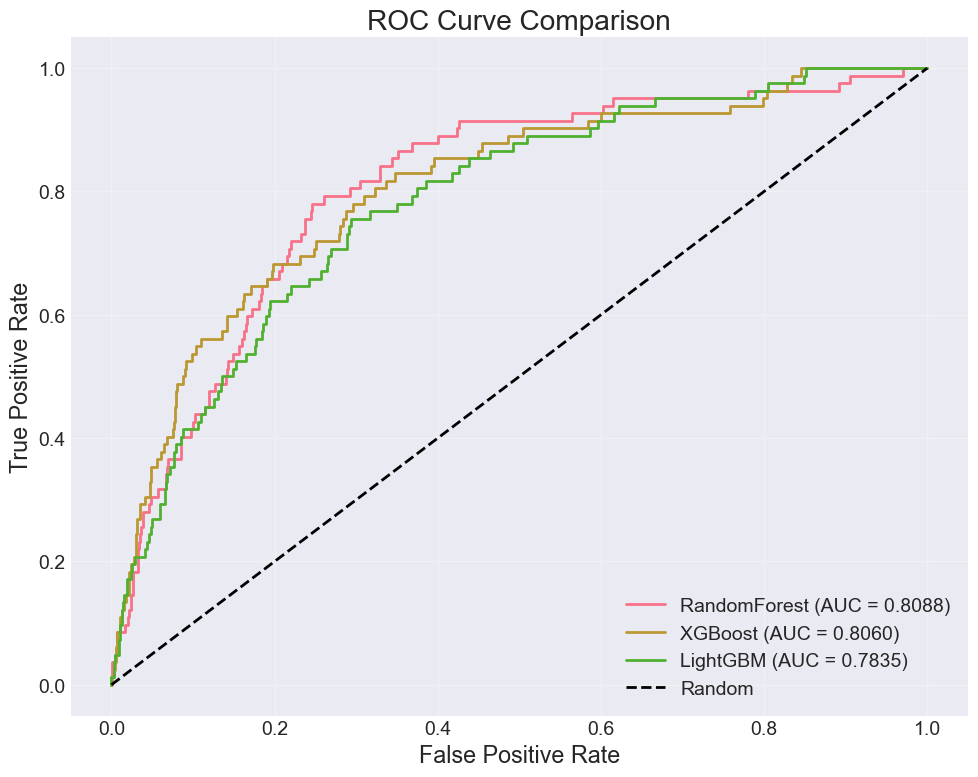


[7.2] Confusion Matrix
----------------------------------------
 Saved: outputs/confusion_matrix.png


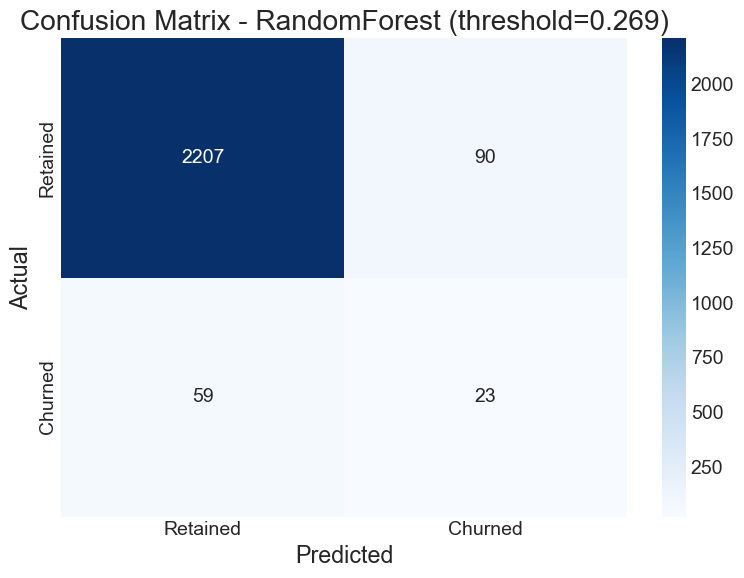


[7.3] Uplift Curves
----------------------------------------
 Saved: outputs/uplift_curves.png


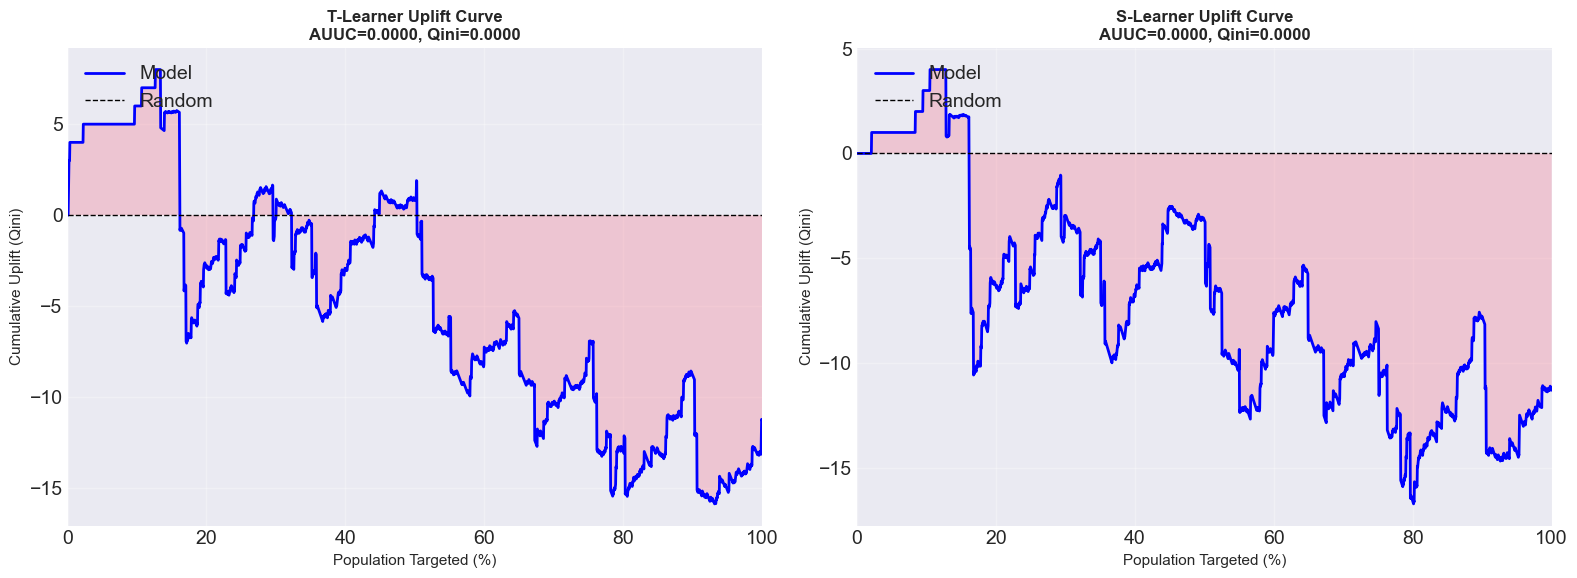

In [33]:
# Create outputs directory
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# 7.1 ROC Curves
print("\n[7.1] ROC Curves")
print("-" * 40)

fig, ax = plt.subplots(figsize=(10, 8))
for name, pred_proba in [("RandomForest", rf_pred_proba),
                          ("XGBoost",      xgb_pred_proba),
                          ("LightGBM",     lgb_pred_proba)]:
    fpr, tpr, _ = roc_curve(y_val, pred_proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / 'roc_curves.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'roc_curves.png'}")
plt.show()
plt.close()

# 7.2 Confusion Matrix  (use optimal threshold, not default 0.5)
print("\n[7.2] Confusion Matrix")
print("-" * 40)

best_pred_proba_val = best_model.predict_proba(X_val_scaled)[:, 1]
best_pred = (best_pred_proba_val >= best_thresh).astype(int)
cm = confusion_matrix(y_val, best_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_model_name} (threshold={best_thresh:.3f})')
plt.tight_layout()
plt.savefig(output_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'confusion_matrix.png'}")
plt.show()
plt.close()

# 7.3 Uplift Curves
print("\n[7.3] Uplift Curves")
print("-" * 40)

# Always flatten uplift arrays — CausalML predict() can return 2-D arrays
uplift_t_flat = np.asarray(uplift_t).flatten()
uplift_s_flat = np.asarray(uplift_s).flatten()

def plot_uplift_curve(y_true, uplift_scores, treatment, ax, title):
    """Plot Qini (cumulative uplift) curve."""
    # Guarantee 1-D
    uplift_scores = np.asarray(uplift_scores).flatten()
    y_true        = np.asarray(y_true).flatten()
    treatment     = np.asarray(treatment).flatten()

    sorted_idx = np.argsort(-uplift_scores)
    y_sorted = y_true[sorted_idx]
    t_sorted = treatment[sorted_idx]

    n = len(y_sorted)
    cum_treat_out  = np.zeros(n + 1)
    cum_ctrl_out   = np.zeros(n + 1)
    cum_treat_size = np.zeros(n + 1)
    cum_ctrl_size  = np.zeros(n + 1)

    for i in range(n):
        if t_sorted[i] == 1:
            cum_treat_out[i+1]  = cum_treat_out[i]  + float(y_sorted[i])
            cum_treat_size[i+1] = cum_treat_size[i] + 1
            cum_ctrl_out[i+1]   = cum_ctrl_out[i]
            cum_ctrl_size[i+1]  = cum_ctrl_size[i]
        else:
            cum_ctrl_out[i+1]   = cum_ctrl_out[i]   + float(y_sorted[i])
            cum_ctrl_size[i+1]  = cum_ctrl_size[i]  + 1
            cum_treat_out[i+1]  = cum_treat_out[i]
            cum_treat_size[i+1] = cum_treat_size[i]

    qini_curve = np.zeros(n + 1)
    for i in range(1, n + 1):
        if cum_treat_size[i] > 0 and cum_ctrl_size[i] > 0:
            qini_curve[i] = (cum_treat_out[i]
                             - (cum_treat_size[i] / cum_ctrl_size[i]) * cum_ctrl_out[i])

    pct = np.linspace(0, 100, n + 1)
    ax.plot(pct, qini_curve, 'b-', linewidth=2, label='Model')
    ax.plot([0, 100], [0, 0], 'k--', linewidth=1, label='Random')
    ax.fill_between(pct, qini_curve, 0, alpha=0.3)
    ax.set_xlabel('Population Targeted (%)', fontsize=11)
    ax.set_ylabel('Cumulative Uplift (Qini)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 100])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_uplift_curve(y_val, uplift_t_flat, t_val, axes[0],
                  f'T-Learner Uplift Curve\nAUUC={auuc_t:.4f}, Qini={qini_t:.4f}')
plot_uplift_curve(y_val, uplift_s_flat, t_val, axes[1],
                  f'S-Learner Uplift Curve\nAUUC={auuc_s:.4f}, Qini={qini_s:.4f}')
plt.tight_layout()
plt.savefig(output_dir / 'uplift_curves.png', dpi=300, bbox_inches='tight')
print(f" Saved: {output_dir / 'uplift_curves.png'}")
plt.show()
plt.close()


In [34]:
print("\n" + "=" * 80)
print("SECTION 8: GENERATING RECOMMENDATIONS")
print("=" * 80)

churn_proba_val = best_model.predict_proba(X_val_scaled)[:, 1]

best_uplift_scores_flat = best_uplift_scores.flatten() if len(best_uplift_scores.shape) > 1 else best_uplift_scores # Flatten the array

recommendations = pd.DataFrame({
    'customer_index': range(len(X_val)),
    'churn_probability': churn_proba_val,
    'uplift_score': best_uplift_scores_flat,
    'actual_treatment': t_val,
    'actual_outcome': y_val
})

# Priority score
recommendations['priority_score'] = (
    recommendations['churn_probability'] * 0.6 + 
    recommendations['uplift_score'] * 0.4
)

# Assign interventions
def assign_intervention(row):
    if row['churn_probability'] > 0.7 and row['uplift_score'] > 0.05:
        return 'Premium_Support'
    elif row['churn_probability'] > 0.5 and row['uplift_score'] > 0.03:
        return 'Discount_20pct'
    elif row['uplift_score'] > 0.03:
        return 'Personalized_Outreach'
    elif row['churn_probability'] > 0.5:
        return 'Feature_Recommendation'
    else:
        return 'No_Action'

recommendations['recommended_intervention'] = recommendations.apply(assign_intervention, axis=1)
recommendations = recommendations.sort_values('priority_score', ascending=False)

print(f"Total customers: {len(recommendations):,}")
print(f"\nIntervention Distribution:")
print(recommendations['recommended_intervention'].value_counts())

# Save recommendations
recommendations.to_csv(output_dir / 'customer_recommendations.csv', index=False)
print(f"\n Recommendations saved: {output_dir / 'customer_recommendations.csv'}")

# Top 10
print("\n[8.1] TOP 10 PRIORITY CUSTOMERS")
print("-" * 40)
top_10 = recommendations.head(10)[
    ['customer_index', 'churn_probability', 'uplift_score', 
     'priority_score', 'recommended_intervention']
]
print(top_10.to_string(index=False))


SECTION 8: GENERATING RECOMMENDATIONS
Total customers: 2,379

Intervention Distribution:
recommended_intervention
No_Action                2371
Personalized_Outreach       8
Name: count, dtype: int64

 Recommendations saved: outputs/customer_recommendations.csv

[8.1] TOP 10 PRIORITY CUSTOMERS
----------------------------------------
 customer_index  churn_probability  uplift_score  priority_score recommended_intervention
            474           0.375264           1.0        0.625158    Personalized_Outreach
           1176           0.291221           1.0        0.574733    Personalized_Outreach
            934           0.290150           1.0        0.574090    Personalized_Outreach
            404           0.276526           1.0        0.565916    Personalized_Outreach
            451           0.268288           1.0        0.560973    Personalized_Outreach
            856           0.246276           1.0        0.547765    Personalized_Outreach
           1392           0.24157

In [35]:
print("\n" + "=" * 80)
print("SECTION 9: FINAL TEST SET EVALUATION")
print("=" * 80)

# ── 9.1 Churn Prediction on Test Set ─────────────────────────────────────────
print("\n[9.1] CHURN PREDICTION - TEST SET")
print("-" * 40)

test_churn_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"Prediction probability distribution:")
print(f"  Min: {test_churn_pred_proba.min():.4f}  Max: {test_churn_pred_proba.max():.4f}")
print(f"  Mean: {test_churn_pred_proba.mean():.4f}  Median: {np.median(test_churn_pred_proba):.4f}")

# Use the optimal threshold carried over from Section 5
print(f"\nUsing optimal threshold from validation: {best_thresh:.4f}")
test_churn_pred = (test_churn_pred_proba >= best_thresh).astype(int)

unique_preds, counts = np.unique(test_churn_pred, return_counts=True)
print(f"Prediction distribution:")
for pred, count in zip(unique_preds, counts):
    print(f"  Class {pred}: {count:>5,} ({count/len(test_churn_pred):.2%})")

test_auc       = roc_auc_score(y_test, test_churn_pred_proba)
test_f1        = f1_score(y_test, test_churn_pred, zero_division=0)
test_precision = precision_score(y_test, test_churn_pred, zero_division=0)
test_recall    = recall_score(y_test, test_churn_pred, zero_division=0)

print(f"\nFinal Test Performance ({best_model_name}):")
print(f"  AUC-ROC:   {test_auc:.4f} {'Yes' if test_auc >= 0.85 else 'No'} (Target: >= 0.85)")
print(f"  F1-Score:  {test_f1:.4f} {'Yes' if test_f1 >= 0.75 else 'No'} (Target: >= 0.75)")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")

# ── 9.2 Uplift Modeling on Test Set ──────────────────────────────────────────
print("\n[9.2] UPLIFT MODELING - TEST SET")
print("-" * 40)

test_uplift = best_uplift_model.predict(X_test_scaled)
test_uplift_flat = test_uplift.flatten() if test_uplift.ndim > 1 else test_uplift

print(f"Test set treatment distribution:")
print(f"  Control (t=0): {(t_test == 0).sum():>5,} ({(t_test == 0).mean():.2%})")
print(f"  Treated (t=1): {(t_test == 1).sum():>5,} ({(t_test == 1).mean():.2%})")
print(f"\nTest uplift statistics:")
print(f"  Mean: {test_uplift_flat.mean():.4f}  Std: {test_uplift_flat.std():.4f}")
print(f"  Min:  {test_uplift_flat.min():.4f}  Max: {test_uplift_flat.max():.4f}")

t_test_str = t_test.astype(str)   # CausalML requires string treatment labels
df_test = pd.DataFrame({'y': y_test, 't': t_test_str, 'uplift': test_uplift_flat})

try:
    test_auuc = auuc_score(df_test, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    print(f"\nAUUC calculated: {test_auuc:.4f}")
except Exception as e:
    print(f"\nAUUC error: {str(e)[:80]}")
    test_auuc = 0.0

try:
    test_qini = qini_score(df_test, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    print(f"Qini calculated: {test_qini:.4f}")
except Exception as e:
    print(f"Qini error: {str(e)[:80]}")
    test_qini = 0.0

print(f"\nFinal Test Performance ({best_uplift_name}):")
print(f"  AUUC:       {test_auuc:.4f}")
print(f"  Qini Coeff: {test_qini:.4f} {'Yes' if test_qini > 0.1 else 'No'} (Target: > 0.1)")



SECTION 9: FINAL TEST SET EVALUATION

[9.1] CHURN PREDICTION - TEST SET
----------------------------------------
Prediction probability distribution:
  Min: 0.0176  Max: 0.4341
  Mean: 0.1354  Median: 0.1224

Using optimal threshold from validation: 0.2686
Prediction distribution:
  Class 0: 2,270 (95.38%)
  Class 1:   110 (4.62%)

Final Test Performance (RandomForest):
  AUC-ROC:   0.8165 No (Target: >= 0.85)
  F1-Score:  0.1667 No (Target: >= 0.75)
  Precision: 0.1455
  Recall:    0.1951

[9.2] UPLIFT MODELING - TEST SET
----------------------------------------
Test set treatment distribution:
  Control (t=0):   543 (22.82%)
  Treated (t=1): 1,837 (77.18%)

Test uplift statistics:
  Mean: 0.0034  Std: 0.0647
  Min:  -1.0000  Max: 1.0000

AUUC error: No objects to concatenate
Qini error: No objects to concatenate

Final Test Performance (T-Learner):
  AUUC:       0.0000
  Qini Coeff: 0.0000 No (Target: > 0.1)


In [36]:
# ============================================================================
# SECTION 6.5: NATIVE UPLIFT TREES COMPARISON (ADVISOR REQUIREMENT)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 6.5: META-LEARNERS VS NATIVE UPLIFT TREES COMPARISON")
print("=" * 80)

print("\n[6.5.1] TRAINING NATIVE UPLIFT RANDOM FOREST")
print("-" * 40)

from causalml.inference.tree import UpliftRandomForestClassifier

# control_name MUST be a string matching the treatment column values
uplift_rf = UpliftRandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    evaluationFunction='KL',
    control_name='0',          # string '0' matches t_val.astype(str)
    random_state=RANDOM_STATE
)

print("Training UpliftRandomForestClassifier...")
start_time = time.time()

# CausalML UpliftRF needs string treatment labels
t_val_str = t_val.astype(str)
uplift_rf.fit(X=X_val_scaled, treatment=t_val_str, y=y_val)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

# Predict uplift scores
uplift_native = uplift_rf.predict(X_val_scaled)
if uplift_native.ndim > 1:
    uplift_native = uplift_native[:, 1] if uplift_native.shape[1] > 1 else uplift_native[:, 0]

print(f"Uplift scores: shape={uplift_native.shape}  mean={uplift_native.mean():.4f}  std={uplift_native.std():.4f}")

# ── Evaluate ──────────────────────────────────────────────────────────────────
print("\n[6.5.2] EVALUATING NATIVE UPLIFT MODEL")
print("-" * 40)

df_val_native = pd.DataFrame({'y': y_val, 't': t_val_str, 'uplift': uplift_native})

try:
    auuc_native = auuc_score(df_val_native, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    print(f"AUUC: {auuc_native:.4f}")
except Exception as e:
    print(f"AUUC error: {str(e)[:80]}")
    auuc_native = 0.0

try:
    qini_native = qini_score(df_val_native, outcome_col='y', treatment_col='t', treatment_effect_col='uplift')
    print(f"Qini: {qini_native:.4f}")
except Exception as e:
    print(f"Qini error: {str(e)[:80]}")
    qini_native = 0.0

# ── Compare all three ─────────────────────────────────────────────────────────
print("\n[6.5.3] COMPARISON: META-LEARNERS VS NATIVE UPLIFT TREES")
print("=" * 80)

comparison_results = pd.DataFrame([
    {'Model': 'T-Learner',         'Type': 'Meta-Learner',      'Base': 'RandomForest',
     'Qini': qini_t,  'AUUC': auuc_t,  'Mean Uplift': uplift_t.mean(), 'Std Uplift': uplift_t.std()},
    {'Model': 'S-Learner',         'Type': 'Meta-Learner',      'Base': 'RandomForest',
     'Qini': qini_s,  'AUUC': auuc_s,  'Mean Uplift': uplift_s.mean(), 'Std Uplift': uplift_s.std()},
    {'Model': 'UpliftRandomForest', 'Type': 'Native Uplift Tree', 'Base': 'Built-in',
     'Qini': qini_native, 'AUUC': auuc_native, 'Mean Uplift': uplift_native.mean(), 'Std Uplift': uplift_native.std()},
])

print(comparison_results.to_string(index=False))

best_idx = comparison_results['Qini'].idxmax()
best_row = comparison_results.iloc[best_idx]
print(f"\nBEST MODEL: {best_row['Model']}  Qini: {best_row['Qini']:.4f}  AUUC: {best_row['AUUC']:.4f}")

comparison_results.to_csv(output_dir / 'uplift_comparison_results.csv', index=False)
print(f"Saved: {output_dir / 'uplift_comparison_results.csv'}")

# Select best for downstream use
if qini_native > max(qini_t, qini_s):
    best_uplift_model_final = uplift_rf
    best_uplift_name_final  = "UpliftRandomForest (Native)"
    best_uplift_scores_final = uplift_native
    best_qini_final = qini_native;  best_auuc_final = auuc_native
elif qini_t > qini_s:
    best_uplift_model_final = tlearner
    best_uplift_name_final  = "T-Learner (Meta)"
    best_uplift_scores_final = uplift_t
    best_qini_final = qini_t;  best_auuc_final = auuc_t
else:
    best_uplift_model_final = slearner
    best_uplift_name_final  = "S-Learner (Meta)"
    best_uplift_scores_final = uplift_s
    best_qini_final = qini_s;  best_auuc_final = auuc_s

print(f"Selected for final recommendations: {best_uplift_name_final}  Qini: {best_qini_final:.4f}")



SECTION 6.5: META-LEARNERS VS NATIVE UPLIFT TREES COMPARISON

[6.5.1] TRAINING NATIVE UPLIFT RANDOM FOREST
----------------------------------------
Training UpliftRandomForestClassifier...
Training completed in 7.57 seconds
Uplift scores: shape=(2379,)  mean=-0.0148  std=0.0306

[6.5.2] EVALUATING NATIVE UPLIFT MODEL
----------------------------------------
AUUC error: No objects to concatenate
Qini error: No objects to concatenate

[6.5.3] COMPARISON: META-LEARNERS VS NATIVE UPLIFT TREES
             Model               Type         Base  Qini  AUUC  Mean Uplift  Std Uplift
         T-Learner       Meta-Learner RandomForest   0.0   0.0     0.001681    0.071002
         S-Learner       Meta-Learner RandomForest   0.0   0.0     0.000000    0.000000
UpliftRandomForest Native Uplift Tree     Built-in   0.0   0.0    -0.014775    0.030583

BEST MODEL: T-Learner  Qini: 0.0000  AUUC: 0.0000
Saved: outputs/uplift_comparison_results.csv
Selected for final recommendations: S-Learner (Meta)  Qin


[6.6] CREATING COMPARISON VISUALIZATIONS
----------------------------------------
Saved: outputs/uplift_model_comparison.png


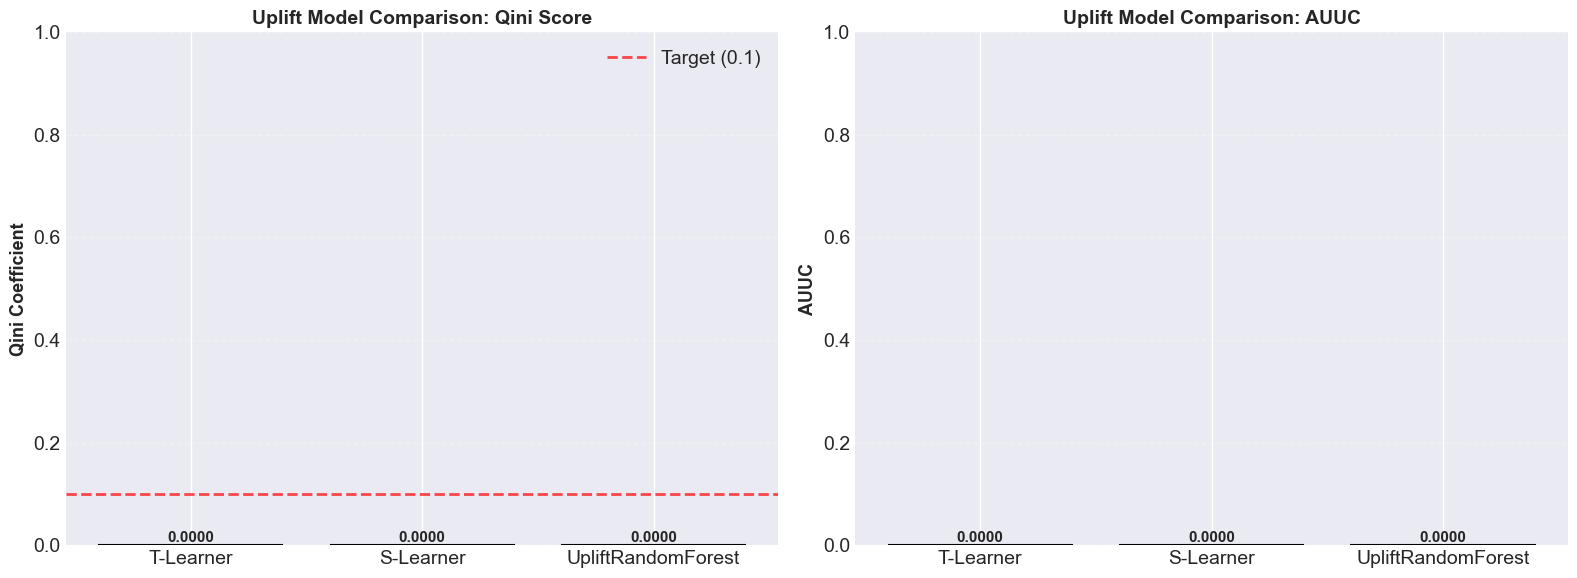


Creating side-by-side uplift curves...
Saved: outputs/uplift_curves_comparison.png


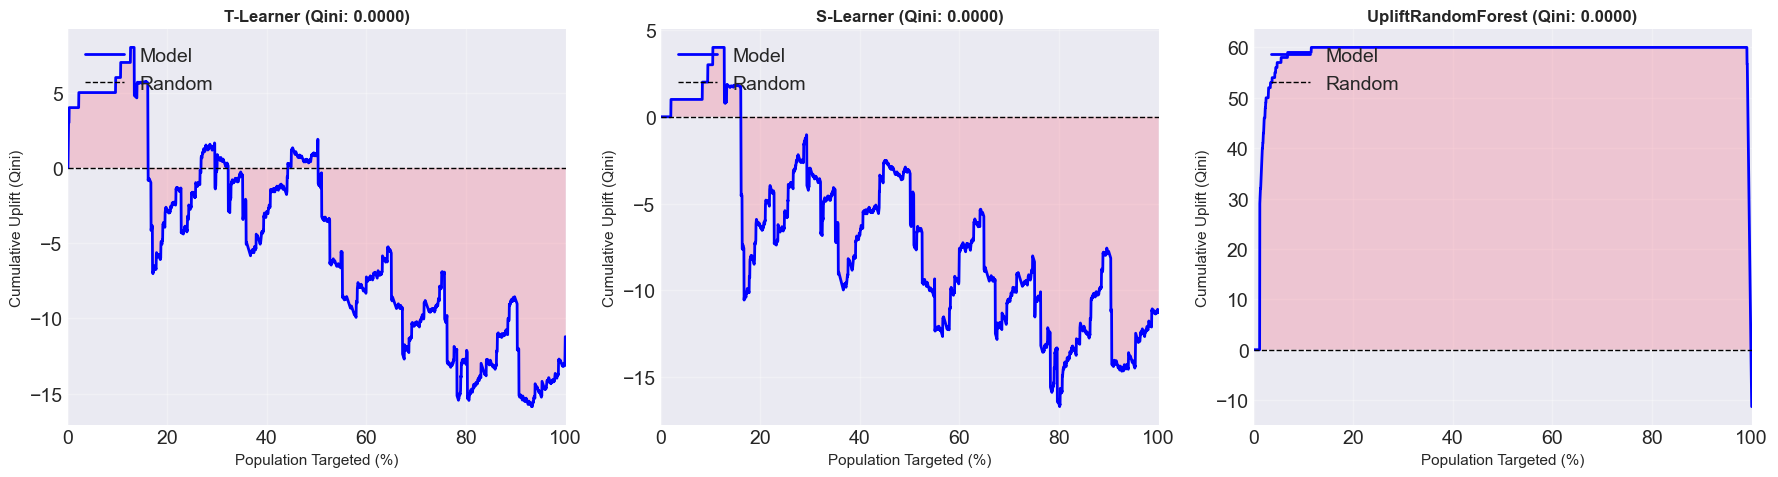

In [37]:
# ============================================================================
# SECTION 6.6: UPLIFT MODEL COMPARISON VISUALIZATIONS
# ============================================================================

print("\n[6.6] CREATING COMPARISON VISUALIZATIONS")
print("-" * 40)

# ── Bar charts: Qini & AUUC ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models      = comparison_results['Model'].tolist()
qini_scores = comparison_results['Qini'].tolist()
auuc_scores = comparison_results['AUUC'].tolist()

base_colors = ['#0066CC', '#00A896', '#FF6B35']

for ax, scores, ylabel, title in [
    (axes[0], qini_scores, 'Qini Coefficient',   'Uplift Model Comparison: Qini Score'),
    (axes[1], auuc_scores, 'AUUC',               'Uplift Model Comparison: AUUC'),
]:
    colors = base_colors.copy()
    colors[int(np.argmax(scores))] = '#FFD700'
    ax.bar(models, scores, color=colors, edgecolor='black', linewidth=1.5)
    for j, (m, v) in enumerate(zip(models, scores)):
        ax.text(j, v + max(scores) * 0.02, f'{v:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(scores) * 1.2 if max(scores) > 0 else 1)

axes[0].axhline(y=0.1, color='red', linestyle='--', linewidth=2,
                label='Target (0.1)', alpha=0.7)
axes[0].legend(loc='upper right')

plt.tight_layout()
plt.savefig(output_dir / 'uplift_model_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'uplift_model_comparison.png'}")
plt.show()

# ── Side-by-side Qini curves for all three models ────────────────────────────
print("\nCreating side-by-side uplift curves...")

# Flatten all uplift arrays before plotting (CausalML returns 2-D arrays)
uplift_t_flat      = np.asarray(uplift_t).flatten()
uplift_s_flat      = np.asarray(uplift_s).flatten()
uplift_native_flat = np.asarray(uplift_native).flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_uplift_curve(y_val, uplift_t_flat,      t_val, axes[0],
                  f'T-Learner (Qini: {qini_t:.4f})')
plot_uplift_curve(y_val, uplift_s_flat,      t_val, axes[1],
                  f'S-Learner (Qini: {qini_s:.4f})')
plot_uplift_curve(y_val, uplift_native_flat, t_val, axes[2],
                  f'UpliftRandomForest (Qini: {qini_native:.4f})')

plt.tight_layout()
plt.savefig(output_dir / 'uplift_curves_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'uplift_curves_comparison.png'}")
plt.show()



SECTION 6.7: SHAP ANALYSIS FOR MODEL EXPLAINABILITY

[6.7.1] INITIALIZING SHAP EXPLAINER
----------------------------------------
Using RandomForest for SHAP analysis...
SHAP explainer created

[6.7.2] CALCULATING SHAP VALUES
----------------------------------------
Analyzing sample of 1000 customers...
Computing SHAP values (this may take 1-2 minutes)...
SHAP values calculated in 1.2s
   SHAP values shape: (1000, 178)
   Features: 178

[6.7.3] SHAP SUMMARY PLOT
----------------------------------------
Saved: outputs/shap_summary_plot.png


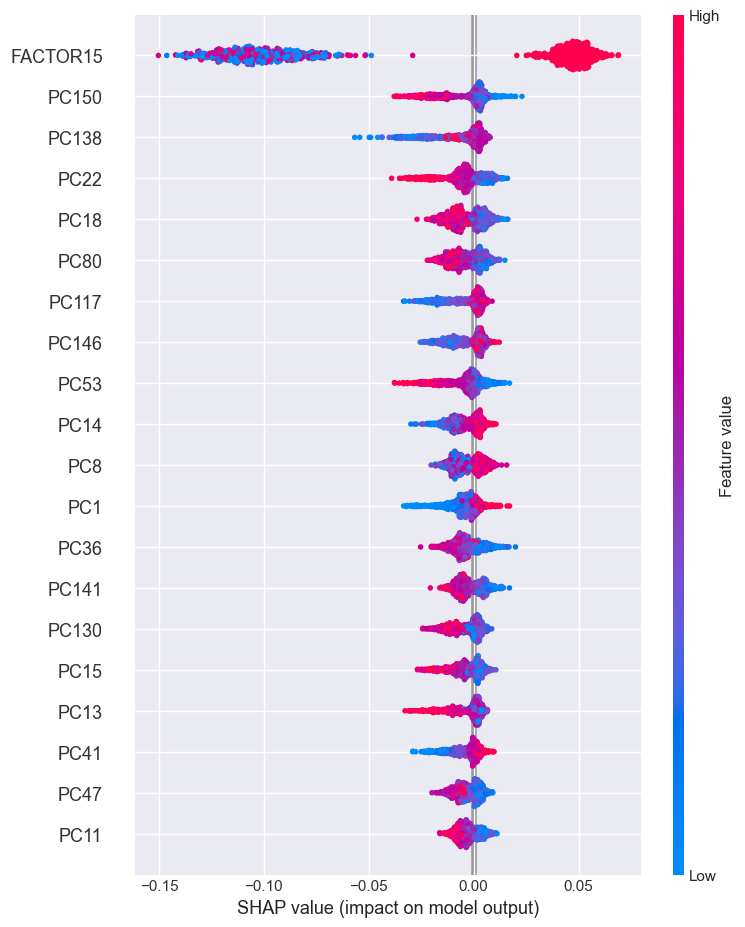


[6.7.4] SHAP FEATURE IMPORTANCE BAR CHART
----------------------------------------
Saved: outputs/shap_feature_importance.png


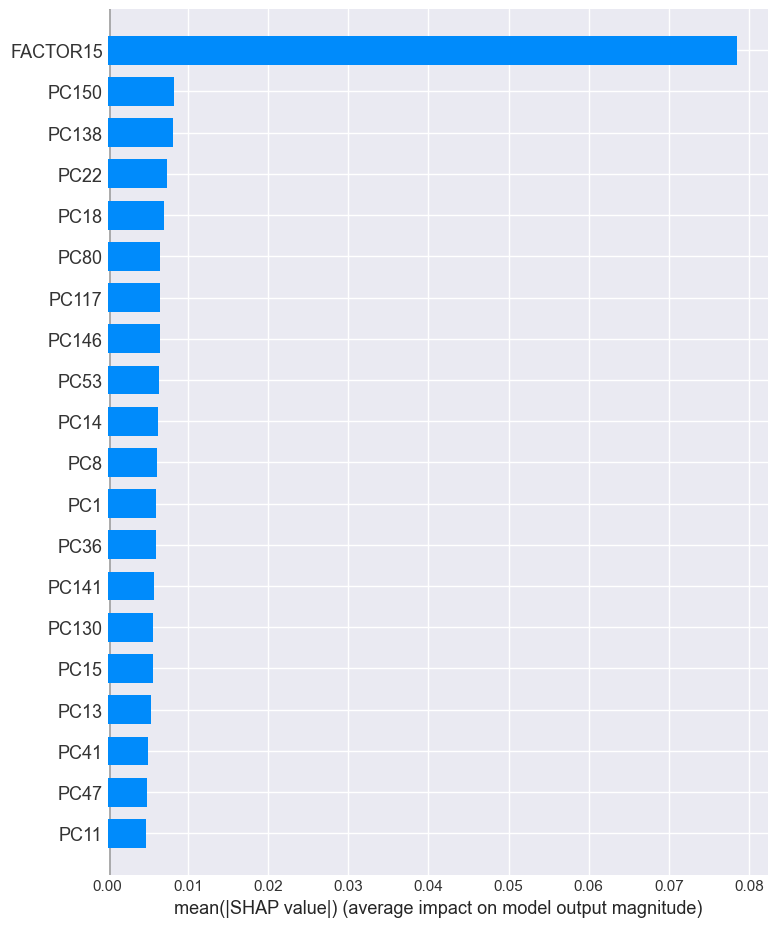


[6.7.5] TOP 10 MOST IMPORTANT FEATURES

Rank  Feature          Mean |SHAP|  Description
------------------------------------------------------------
 1.   FACTOR15             0.0784  Categorical feature
 2.   PC150                0.0083  Principal Component (anonymized)
 3.   PC138                0.0081  Principal Component (anonymized)
 4.   PC22                 0.0074  Principal Component (anonymized)
 5.   PC18                 0.0070  Principal Component (anonymized)
 6.   PC80                 0.0065  Principal Component (anonymized)
 7.   PC117                0.0065  Principal Component (anonymized)
 8.   PC146                0.0065  Principal Component (anonymized)
 9.   PC53                 0.0064  Principal Component (anonymized)
10.   PC14                 0.0063  Principal Component (anonymized)

[6.7.6] INDIVIDUAL CUSTOMER EXPLANATIONS

TOP 3 HIGH-RISK CUSTOMERS WITH SHAP EXPLANATIONS:

Customer #1  (Sample Index: 245)
  Churn Probability: 44.7%
  Uplift Score:      0.0000



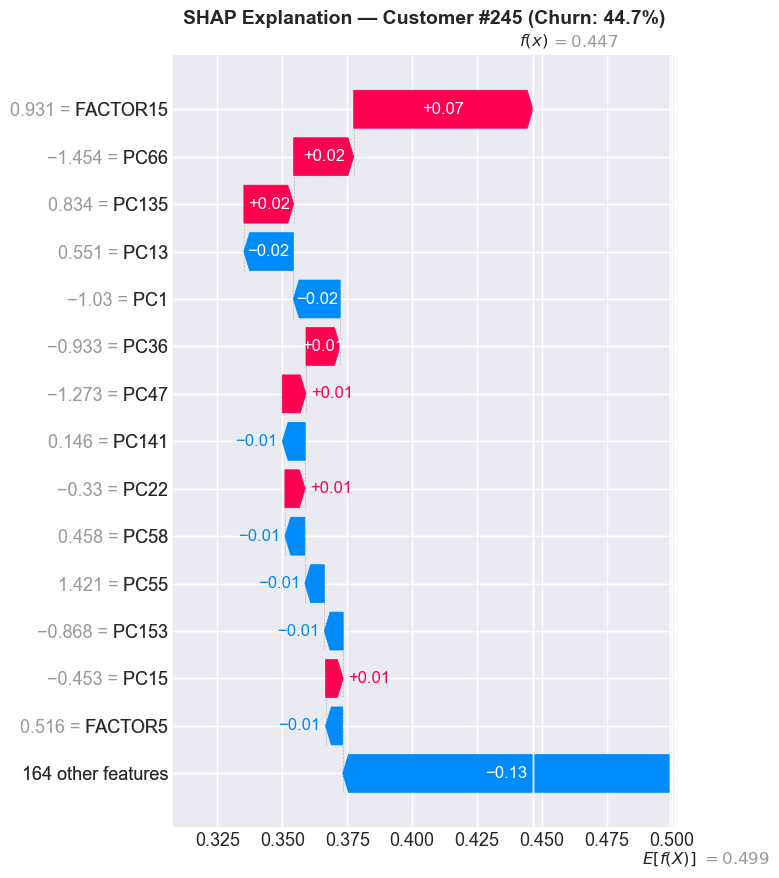


SHAP ANALYSIS COMPLETE
  Top feature : FACTOR15
  Model used  : RandomForest
  Sample size : 1000 customers
  Features    : 178


In [38]:
# ============================================================================
# SECTION 6.7: SHAP EXPLAINABILITY ANALYSIS (ADVISOR REQUIREMENT)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 6.7: SHAP ANALYSIS FOR MODEL EXPLAINABILITY")
print("=" * 80)

print("\n[6.7.1] INITIALIZING SHAP EXPLAINER")
print("-" * 40)

print(f"Using {best_model_name} for SHAP analysis...")
explainer = shap.TreeExplainer(best_model)
print("SHAP explainer created")

# ── 6.7.2 Calculate SHAP values ──────────────────────────────────────────────
print("\n[6.7.2] CALCULATING SHAP VALUES")
print("-" * 40)

sample_size = min(1000, len(X_val_scaled))
print(f"Analyzing sample of {sample_size} customers...")

X_sample = X_val_scaled[:sample_size]
y_sample = y_val[:sample_size]

print("Computing SHAP values (this may take 1-2 minutes)...")
start_time = time.time()
shap_values_raw = explainer.shap_values(X_sample)
elapsed = time.time() - start_time
print(f"SHAP values calculated in {elapsed:.1f}s")

# Normalise shap_values to always be 2-D (n_samples, n_features) for class 1.
# SHAP can return:
#   list  [class0_arr, class1_arr]  — older SHAP / sklearn trees
#   3-D array (n_samples, n_features, n_classes) — newer SHAP
#   2-D array (n_samples, n_features)             — XGBoost / binary
shap_values_raw = np.array(shap_values_raw) if not isinstance(shap_values_raw, list) else shap_values_raw

if isinstance(shap_values_raw, list):
    shap_values = np.array(shap_values_raw[1])          # list → take class 1
elif shap_values_raw.ndim == 3:                          # (n_samples, n_features, n_classes)
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw                        # already 2-D

# expected_value: pick class-1 scalar
ev = np.asarray(explainer.expected_value).flatten()
expected_value = float(ev[1] if len(ev) > 1 else ev[0])

print(f"   SHAP values shape: {shap_values.shape}")

feature_names = [col for col in df.columns if col not in ['t', 'y']]
print(f"   Features: {len(feature_names)}")

# ── 6.7.3 Summary plot ───────────────────────────────────────────────────────
print("\n[6.7.3] SHAP SUMMARY PLOT")
print("-" * 40)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names, max_display=20, show=False)
plt.tight_layout()
plt.savefig(output_dir / 'shap_summary_plot.png', dpi=300,
            bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'shap_summary_plot.png'}")
plt.show()

# ── 6.7.4 Feature importance bar ─────────────────────────────────────────────
print("\n[6.7.4] SHAP FEATURE IMPORTANCE BAR CHART")
print("-" * 40)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names, plot_type="bar",
                  max_display=20, show=False)
plt.tight_layout()
plt.savefig(output_dir / 'shap_feature_importance.png', dpi=300,
            bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'shap_feature_importance.png'}")
plt.show()

# ── 6.7.5 Top 10 features ────────────────────────────────────────────────────
print("\n[6.7.5] TOP 10 MOST IMPORTANT FEATURES")
print("=" * 80)

# mean_abs_shap is 1-D (n_features,) because shap_values is 2-D
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_indices   = np.argsort(mean_abs_shap)[-10:][::-1]   # 1-D integer array

print("\nRank  Feature          Mean |SHAP|  Description")
print("-" * 60)
for rank, idx in enumerate(top_indices, 1):
    idx = int(idx)   # ensure plain Python int for list indexing
    feature_name = feature_names[idx]
    shap_val     = float(mean_abs_shap[idx])
    desc = ("Principal Component (anonymized)" if feature_name.startswith('PC')
            else "Categorical feature" if feature_name.startswith('FACTOR')
            else "Other feature")
    print(f"{rank:2d}.   {feature_name:15s}  {shap_val:10.4f}  {desc}")

# ── 6.7.6 Individual customer explanations ───────────────────────────────────
print("\n[6.7.6] INDIVIDUAL CUSTOMER EXPLANATIONS")
print("=" * 80)

churn_probs_sample = best_model.predict_proba(X_sample)[:, 1]
high_risk_indices  = np.argsort(churn_probs_sample)[-3:][::-1]

print("\nTOP 3 HIGH-RISK CUSTOMERS WITH SHAP EXPLANATIONS:")
for i, customer_idx in enumerate(high_risk_indices, 1):
    customer_idx = int(customer_idx)
    print(f"\n{"="*80}")
    print(f"Customer #{i}  (Sample Index: {customer_idx})")
    print(f"  Churn Probability: {churn_probs_sample[customer_idx]:.1%}")

    if customer_idx < len(np.asarray(best_uplift_scores_final).flatten()):
        uplift_flat = np.asarray(best_uplift_scores_final).flatten()
        print(f"  Uplift Score:      {uplift_flat[customer_idx]:.4f}")

    customer_shap  = shap_values[customer_idx]               # 1-D (n_features,)
    top_feat_idx   = np.argsort(np.abs(customer_shap))[-5:][::-1]

    print(f"\n  Top 5 Risk Factors:")
    print(f"  {'Rank':<5} {'Feature':<16} {'Value':>8} {'SHAP':>8}  Impact")
    print(f"  {'-'*60}")
    for rank, feat_idx in enumerate(top_feat_idx, 1):
        feat_idx   = int(feat_idx)
        fname      = feature_names[feat_idx]
        shap_value = float(customer_shap[feat_idx])
        fval       = float(X_sample[customer_idx, feat_idx])
        direction  = "Increases churn risk" if shap_value > 0 else "Decreases churn risk"
        print(f"  {rank}.    {fname:<16} {fval:8.2f} {shap_value:+8.3f}  {direction}")

# ── 6.7.7 Waterfall plot ─────────────────────────────────────────────────────
print("\n[6.7.7] SHAP WATERFALL PLOT FOR HIGHEST-RISK CUSTOMER")
print("-" * 40)

customer_idx = int(high_risk_indices[0])

plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=expected_value,
        data=X_sample[customer_idx],
        feature_names=feature_names
    ),
    max_display=15,
    show=False
)
plt.title(
    f'SHAP Explanation — Customer #{customer_idx} (Churn: {churn_probs_sample[customer_idx]:.1%})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(output_dir / 'shap_waterfall_example.png', dpi=300,
            bbox_inches='tight', facecolor='white')
print(f"Saved: {output_dir / 'shap_waterfall_example.png'}")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("SHAP ANALYSIS COMPLETE")
print("=" * 80)
print(f"  Top feature : {feature_names[int(top_indices[0])]}")
print(f"  Model used  : {best_model_name}")
print(f"  Sample size : {sample_size} customers")
print(f"  Features    : {len(feature_names)}")